# 01 Data Analysis
Inspect raw IDS data, class balance, missing values, and feature types.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

raw_dir = Path.cwd() / "data" / "raw"

if not raw_dir.exists():
    raw_dir = Path.cwd().parent / "data" / "raw"

csv_files = sorted(raw_dir.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {raw_dir}")

print(f"Found {len(csv_files)} CSV files")

file_summary = []
label_counts = []
sample_frames = []

for path in csv_files:
    row_count = 0
    missing_values = 0
    infinity_values = 0
    duplicate_rows = 0
    local_labels = {}

    for chunk in pd.read_csv(
        path,
        chunksize=100_000,
        low_memory=False,
    ):
        chunk.columns = chunk.columns.str.strip()
        row_count += len(chunk)

        missing_values += int(chunk.isna().sum().sum())

        numeric = chunk.select_dtypes(include=np.number)
        infinity_values += int(
            np.isinf(numeric.to_numpy()).sum()
        )

        duplicate_rows += int(chunk.duplicated().sum())

        label_column = next(
            (
                column
                for column in chunk.columns
                if column.lower() == "label"
            ),
            None,
        )

        if label_column is not None:
            counts = (
                chunk[label_column]
                .astype(str)
                .str.strip()
                .value_counts()
            )

            for label, count in counts.items():
                local_labels[label] = (
                    local_labels.get(label, 0) + int(count)
                )

        if len(sample_frames) < 10:
            sample_frames.append(chunk.head(1_000))

    for label, count in local_labels.items():
        label_counts.append({
            "file": path.name,
            "label": label,
            "count": count,
        })

    file_summary.append({
        "file": path.name,
        "rows": row_count,
        "columns": len(chunk.columns),
        "missing_values": missing_values,
        "infinity_values": infinity_values,
        "duplicate_rows_in_chunks": duplicate_rows,
    })

file_summary = pd.DataFrame(file_summary)
label_counts = pd.DataFrame(label_counts)

label_summary = (
    label_counts
    .groupby("label", as_index=False)["count"]
    .sum()
    .sort_values("count", ascending=False)
)

display(file_summary)
display(label_summary)

Found 8 CSV files


,file,rows,columns,missing_values,infinity_values,duplicate_rows_in_chunks
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,79,4,64,1870
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467,79,15,727,47775
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,79,28,216,5404
3,Monday-WorkingHours.pcap_ISCX.csv,529918,79,64,810,17480
4,Thursday-WorkingHours-Afternoon-Infilteration....,288602,79,18,396,28104
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,170366,79,20,250,4829
6,Tuesday-WorkingHours.pcap_ISCX.csv,445909,79,201,327,16647
7,Wednesday-workingHours.pcap_ISCX.csv,692703,79,1008,1586,71964


,label,count
0,BENIGN,2273097
4,DoS Hulk,231073
10,PortScan,158930
2,DDoS,128027
3,DoS GoldenEye,10293
7,FTP-Patator,7938
11,SSH-Patator,5897
6,DoS slowloris,5796
5,DoS Slowhttptest,5499
1,Bot,1966


C:\Users\abhis\AppData\Local\Temp\ipykernel_16808\2284253317.py:12: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
d:\FedGuard-XAI\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


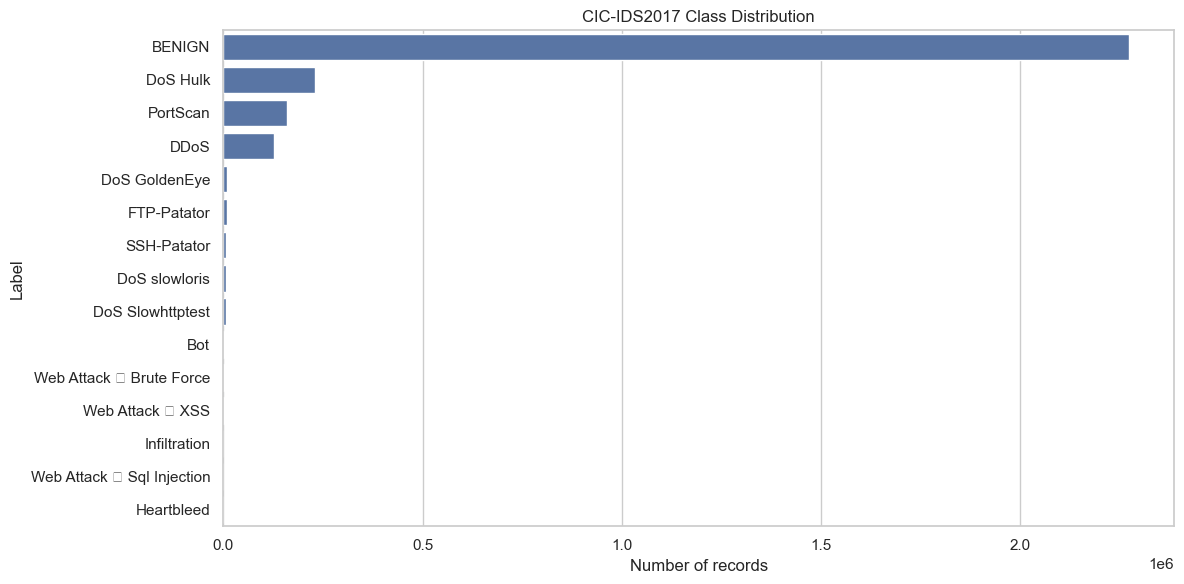

In [4]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.barplot(
    data=label_summary.head(20),
    x="count",
    y="label",
)
plt.title("CIC-IDS2017 Class Distribution")
plt.xlabel("Number of records")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

In [5]:
sample = pd.read_csv(csv_files[0], nrows=100_000, low_memory=False)
sample.columns = sample.columns.str.strip()

display(
    pd.DataFrame({
        "column": sample.columns,
        "dtype": sample.dtypes.astype(str).values,
        "missing_values": sample.isna().sum().values,
        "unique_values": sample.nunique().values,
    })
)

display(sample.select_dtypes(include=np.number).describe().T)

,column,dtype,missing_values,unique_values
0,Destination Port,int64,0,12651
1,Flow Duration,int64,0,86513
2,Total Fwd Packets,int64,0,209
3,Total Backward Packets,int64,0,247
4,Total Length of Fwd Packets,int64,0,2466
...,...,...,...,...
74,Idle Mean,float64,0,15083
75,Idle Std,float64,0,2570
76,Idle Max,int64,0,14156
77,Idle Min,int64,0,21492


d:\FedGuard-XAI\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
d:\FedGuard-XAI\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Destination Port,100000.0,7.053784e+03,1.780276e+04,0.0,80.0,80.0,80.00,65439.0
Flow Duration,100000.0,1.633647e+07,2.997265e+07,0.0,79702.0,1628053.0,9366010.25,119999439.0
Total Fwd Packets,100000.0,4.936110e+00,1.501054e+01,1.0,2.0,3.0,5.00,1757.0
Total Backward Packets,100000.0,4.789730e+00,2.111982e+01,0.0,1.0,4.0,6.00,2942.0
Total Length of Fwd Packets,100000.0,7.312120e+02,3.108364e+03,0.0,26.0,26.0,60.00,120783.0
...,...,...,...,...,...,...,...,...
Active Min,100000.0,1.902981e+05,8.518007e+05,0.0,0.0,0.0,1986.00,100000000.0
Idle Mean,100000.0,1.040617e+07,2.066731e+07,0.0,0.0,0.0,9059748.25,120000000.0
Idle Std,100000.0,3.643645e+06,1.188152e+07,0.0,0.0,0.0,0.00,65300000.0
Idle Max,100000.0,1.298509e+07,2.533758e+07,0.0,0.0,0.0,9116630.25,120000000.0


## Phase 1 Findings

The CIC-IDS2017 dataset contains eight CSV files with 79 columns per file. The files include benign traffic and multiple attack classes, including DoS Hulk, PortScan, DDoS, DoS GoldenEye, FTP-Patator, SSH-Patator, slowloris, Slowhttptest, Bot, Infiltration, and Web Attack categories.

The label distribution is highly imbalanced, with `BENIGN` as the largest class. The audit also identified missing values, positive and negative infinity values, and duplicate rows counted within individual chunks. These issues must be handled during Phase 2 preprocessing. Duplicate counts are chunk-level counts and should not be interpreted as a complete cross-file duplicate count.